In [1]:
import numpy as np
from PIL import Image
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from glob import glob
from torch.utils.data import Dataset, DataLoader, random_split
import torch
print("is_available:", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)
print("torch.version.__version__:", torch.__version__)
print("device_count:", torch.cuda.device_count())


is_available: True
torch.version.cuda: 12.1
torch.version.__version__: 2.5.1
device_count: 1


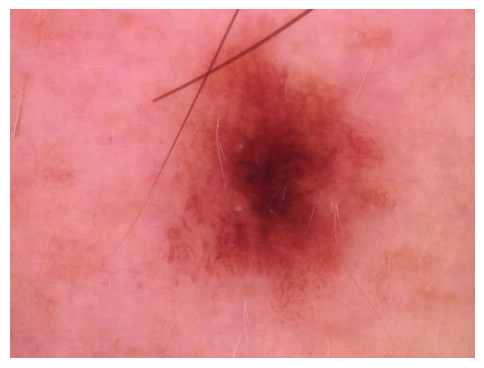

In [2]:
image_folder = r"C:\Users\Val\Documents\Python\MelanomaDetection\HAM10000_Dataset\HAM10000" #CHANGE THE PATH
images = [f for f in os.listdir(image_folder) if f.endswith(".jpg")]
image_path = os.path.join(image_folder, images[0])

# Open image
img = Image.open(image_path)

# Display inline in notebook
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')  # remove axes
plt.show()

In [3]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Val\Documents\Python\MelanomaDetection\HAM10000_Dataset\HAM10000_metadata.csv") #CHANGE THE PATH
print(df.head(5))

     lesion_id  image_id     dx dx_type   age   sex localization       dataset
0  HAM_0000118      3113  nomel   histo  80.0  male        scalp  vidir_modern
1  HAM_0000118       724  nomel   histo  80.0  male        scalp  vidir_modern
2  HAM_0002730      2463  nomel   histo  80.0  male        scalp  vidir_modern
3  HAM_0002730      1355  nomel   histo  80.0  male        scalp  vidir_modern
4  HAM_0001466      7327  nomel   histo  75.0  male          ear  vidir_modern


In [4]:
import os
IMAGE_DIR = r"C:\Users\Val\Documents\Python\MelanomaDetection\HAM10000_Dataset\HAM10000"#CHANGE THE PATH
MASK_DIR  = r"C:\Users\Val\Documents\Python\MelanomaDetection\HAM10000_Dataset\HAM10000_segmentations_lesion_tschandl"#CHANGE THE PATH
CSV_PATH  = r"C:\Users\Val\Documents\Python\MelanomaDetection\HAM10000_Dataset\HAM10000_metadata.csv"#CHANGE THE PATH

# List and sort files
images = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg', '.png'))])
masks  = sorted([f for f in os.listdir(MASK_DIR)  if f.endswith(('.jpg', '.png'))])

# Make sure counts match
assert len(images) == len(masks), "Number of images and masks do not match!"

# Rename files sequentially
for idx, (img_name, mask_name) in enumerate(zip(images, masks)):
    # New filenames
    new_img_name  = f"{idx:05d}.jpg"
    new_mask_name = f"{idx:05d}.png"

    # Rename image and mask
    os.rename(os.path.join(IMAGE_DIR, img_name),
              os.path.join(IMAGE_DIR, new_img_name))
    os.rename(os.path.join(MASK_DIR, mask_name),
              os.path.join(MASK_DIR, new_mask_name))

    # Update CSV: find row with original image_id (without extension)
    base_name = os.path.splitext(img_name)[0]
    # print(img_name, base_name)
    df.loc[df['image_id'] == base_name, 'image_id'] = os.path.splitext(new_img_name)[0]


df.to_csv(CSV_PATH, index=False)
print(f"Renamed {len(images)} images and masks and updated CSV accordingly.")
print("Updated CSV sample:\n", df.head())


C:\Users\Val\AppData\Local\Temp\ipykernel_10196\2390426625.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00000' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['image_id'] == base_name, 'image_id'] = os.path.splitext(new_img_name)[0]


Renamed 10015 images and masks and updated CSV accordingly.
Updated CSV sample:
      lesion_id image_id     dx dx_type   age   sex localization       dataset
0  HAM_0000118     3113  nomel   histo  80.0  male        scalp  vidir_modern
1  HAM_0000118      724  nomel   histo  80.0  male        scalp  vidir_modern
2  HAM_0002730     2463  nomel   histo  80.0  male        scalp  vidir_modern
3  HAM_0002730     1355  nomel   histo  80.0  male        scalp  vidir_modern
4  HAM_0001466     7327  nomel   histo  75.0  male          ear  vidir_modern


In [5]:
import pandas as pd

# assuming your dataframe is called df

mask = df["image_id"].str.contains(r"^ISIC_0\d{4}", na=False)

if mask.any():
    print("Entries with pattern ISIC_0xxxx exist.")
    print(df[mask])
else:
    print(" No entries found with pattern ISIC_0xxxx.")


AttributeError: Can only use .str accessor with string values!

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        if not mid_ch:
            mid_ch = out_ch
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )
    def forward(self, x):
        return self.pool_conv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch, mid_ch=in_ch//2)
        else:
            self.up = nn.ConvTranspose2d(in_ch//2, in_ch//2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # pad in case input sizes differ by 1
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, base_filters=64, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, base_filters)
        self.down1 = Down(base_filters, base_filters*2)
        self.down2 = Down(base_filters*2, base_filters*4)
        self.down3 = Down(base_filters*4, base_filters*8)
        factor = 2 if bilinear else 1
        self.down4 = Down(base_filters*8, base_filters*16 // factor)
        self.up1 = Up(base_filters*16, base_filters*8 // factor, bilinear)
        self.up2 = Up(base_filters*8, base_filters*4 // factor, bilinear)
        self.up3 = Up(base_filters*4, base_filters*2 // factor, bilinear)
        self.up4 = Up(base_filters*2, base_filters, bilinear)
        self.outc = OutConv(base_filters, n_classes)

    def forward(self, x):
        x1 = self.inc(x)      # [B, f, H, W]
        x2 = self.down1(x1)   # [B, 2f, H/2, W/2]
        x3 = self.down2(x2)   # [B, 4f, H/4, W/4]
        x4 = self.down3(x3)   # [B, 8f, H/8, W/8]
        x5 = self.down4(x4)   # bottleneck
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

In [7]:
from torch.utils.data import Dataset, DataLoader
# IMAGE_DIR = "/content/drive/MyDrive/hamdataset/images"
# MASK_DIR  = "/content/drive/MyDrive/hamdataset/segmentation_masks"

class HAMSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_list=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        if image_list:
            self.images = image_list
        else:
            self.images = sorted([f for f in os.listdir(image_dir) if f.endswith(".jpg") or f.endswith(".png")])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, os.path.splitext(img_name)[0] + ".png")  # masks must match names

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale mask

        # Convert to tensors
        image = torch.tensor(np.array(image)/255.0, dtype=torch.float).permute(2,0,1)  # [C,H,W]
        mask  = torch.tensor(np.array(mask)/255.0, dtype=torch.float).unsqueeze(0)     # [1,H,W]

        return image, mask


In [8]:
import random
#Taking 20* of the total dataset to train the U-NET
all_images = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith(".jpg") or f.endswith(".png")])
random.shuffle(all_images)

n_total = 0.1*len(all_images)
n_train = int(0.7 * n_total)
n_val   = int(0.15 * n_total)
n_test  =int(n_total) - n_train - n_val

train_images = all_images[:n_train]
val_images   = all_images[n_train:(n_train+n_val)]
test_images  = all_images[(n_train+n_val):(n_train+n_val+n_test)]

In [9]:
train_dataset = HAMSegDataset(IMAGE_DIR, MASK_DIR, train_images)
val_dataset   = HAMSegDataset(IMAGE_DIR, MASK_DIR, val_images)
test_dataset  = HAMSegDataset(IMAGE_DIR, MASK_DIR, test_images)

In [10]:
print("Dataset prepared:")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Dataset prepared:
Train: 701, Val: 150, Test: 150


In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Initialize U-Net
model = UNet(n_channels=3, n_classes=1)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()  # binary segmentation
optimizer = optim.Adam(model.parameters(), lr=1e-4)


Using device: cuda


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
# Re-initialize the optimizer after moving the model to the correct device
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 30
best_val_loss = float('inf')  # for saving best model

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        # Move images and masks to the device
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            # Move images and masks to the device
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "unet_ham_best.pth")
        print("Saved Best Model")

In [ ]:
# Select only the two columns
df2 = df[["image_id", "dx"]]

# Save to CSV
df2.to_csv("imageid_dx.csv", index=False)

print("✔️ Saved CSV with 2 columns: image_id and dx")

In [ ]:
model = UNet(n_channels=3, n_classes=1, base_filters=64, bilinear=True)
model.load_state_dict(torch.load("unet_ham_best.pth", map_location=device))
model.to(device)
model.eval()

In [ ]:
import os
import torch
import torch.nn.functional as F
from PIL import Image
import cv2
from scipy.stats import skew, kurtosis
import numpy as np
from skimage.feature import local_binary_pattern, hog
from skimage.filters import gabor
from torchvision import transforms

def extract_lbp_features(gray, P=8, R=1):
    lbp = local_binary_pattern(gray, P, R, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0,P+3), range=(0,P+2))
    hist = hist.astype("float") / (hist.sum() + 1e-6)
    return hist

def extract_hog_features(gray):
    features, _ = hog(gray, orientations=9, pixels_per_cell=(8,8),
                      cells_per_block=(2,2), block_norm='L2-Hys', visualize=True)
    return features

def extract_gabor_features(gray, frequencies=[0.1,0.3,0.5]):
    feats = []
    for freq in frequencies:
        filt_real, filt_imag = gabor(gray, frequency=freq)
        feats.append(filt_real.mean())
        feats.append(filt_real.var())
    return np.array(feats)



def extract_color_features(rgb):
    # Convert RGB -> LUV
    luv = cv2.cvtColor(rgb, cv2.COLOR_BGR2Luv)

    # Combine RGB + LUV (6 channels)
    channels = [
        rgb[:,:,0], rgb[:,:,1], rgb[:,:,2],   # R,G,B
        luv[:,:,0], luv[:,:,1], luv[:,:,2]    # L,U,V
    ]

    features = []

    for ch in channels:
        ch = ch.astype(np.float32)
        ch = ch[ch > 0]
        if ch.size == 0:
            features.extend([0,0,0,0,0])
            continue

        ch = ch / (np.max(ch) + 1e-6)
        # Same pattern as your original code: compute, append, continue
        mean = ch.mean()
        minimum = ch.min()
        std = ch.std()
        sk = skew(ch, bias=False)
        kurt = kurtosis(ch, bias=False)

        features.extend([mean, minimum, std, sk, kurt])

    return np.array(features)


def extract_features(masked_rgb, masked_gray):
    lbp_feats = extract_lbp_features(masked_gray)
    hog_feats = extract_hog_features(masked_gray)
    gabor_feats = extract_gabor_features(masked_gray)
    color_feats = extract_color_features(masked_rgb)
    return np.concatenate([lbp_feats, hog_feats, gabor_feats, color_feats])


In [ ]:
features_list = []
image_names = sorted(os.listdir(IMAGE_DIR))
MASK_SAVE_DIR ="/content/drive/MyDrive/hamdataset/mask_saved" #CHANGE THE PATH

# Create the directory if it doesn't exist
os.makedirs(MASK_SAVE_DIR, exist_ok=True)

for img_name in image_names[(n_train+n_val+n_test):]:
    img_path = os.path.join(IMAGE_DIR, img_name)

    # Load and preprocess
    image = Image.open(img_path).convert("RGB")

    # Convert to tensor (using original image size for model input)
    input_tensor = torch.from_numpy(np.array(image).transpose(2,0,1)).float().unsqueeze(0) / 255.0
    input_tensor = input_tensor.to(device)

    # Predict mask
    with torch.no_grad():
        output = model(input_tensor)
        mask = torch.sigmoid(output).squeeze().cpu().numpy()

    # Threshold mask
    mask_binary = (mask > 0.5).astype(np.uint8)

    # Save predicted mask (original size)
    mask_image = Image.fromarray(mask_binary*255)
    mask_image.save(os.path.join(MASK_SAVE_DIR, img_name.replace(".jpg",".png")))

    # Resize mask_binary to match the dimensions of the image used for feature extraction (128,128)
    mask_binary_resized = np.array(Image.fromarray(mask_binary).resize((128, 128), Image.NEAREST))

    # Apply mask to original image for feature extraction
    image_np_resized = np.array(image.resize((128,128)))
    masked_rgb = image_np_resized * mask_binary_resized[:,:,None]      # mask applied to each channel
    masked_gray = np.array(image.convert("L").resize((128,128))) * mask_binary_resized

    # Extract features
    feats = extract_features(masked_rgb, masked_gray)
    features_list.append(feats)

print("Segmentation + feature extraction done for all images.")
features_array = np.array(features_list)
print("Feature matrix shape:", features_array.shape)


In [ ]:
df = df2.sort_values(by="image_id").reset_index(drop=True)
df =df2[(n_train+n_val+n_test):]
print(df.head())
print(len(df))

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

df["binary_label"] = df["dx"].apply(lambda x: 1 if x.lower() == "mel" else 0)


X = features_array
y = df["binary_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n===== Random Forest Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("\n===== XGBoost Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='euclidean'
)

# Train
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

# Evaluation
print("\n===== KNN Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes model
nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)

# Evaluation
print("\n===== Naive Bayes Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
